In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

from src.graphs import StaticGraph
from src.misc import multi_crx
from qiskit import QuantumCircuit, transpile
import itertools
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import os
import pandas as pd

In [2]:
# Create output directory for plots
output_dir = "trotterization_plots"
os.makedirs(output_dir, exist_ok=True)

# Set up publication-quality plotting style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False  # Set to True if you have LaTeX installed
})

In [3]:
# Import required functions
from src.qwalk_dictionary import getOpsCirc
from src.misc import graph_matchings_parallel

# Global storage for gate count data
gate_count_data = []


def build_matching_circuit(n_qubits, n_steps, delta_t, relabeled_edges, matchings):
    """
    Build quantum circuit using matching-based decomposition.
    
    For each Trotter step:
        For each matching:
            For each edge in matching:
                Add single edge circuit
    
    Args:
        n_qubits: Number of qubits
        n_steps: Number of Trotter steps
        delta_t: Time step size
        relabeled_edges: List of edges in relabeled graph
        matchings: List of matchings, where each matching is a list of edges
        
    Returns:
        QuantumCircuit: Complete matching-based circuit
    """
    qc = QuantumCircuit(n_qubits)
    
    # Time per step
    dt = delta_t / n_steps
    
    # Each edge appears in exactly one matching, so we divide time by number of matchings
    # to ensure correct total evolution time
    time_per_edge = dt / len(matchings) if matchings else dt
    
    for step in range(n_steps):
        for matching in matchings:
            for edge in matching:
                # Edge nodes are already binary strings
                node1, node2 = edge
                
                # Ensure they are strings (not integers)
                if isinstance(node1, int):
                    z1 = format(node1, f'0{n_qubits}b')
                else:
                    z1 = str(node1)  # Ensure it's a string
                    
                if isinstance(node2, int):
                    z2 = format(node2, f'0{n_qubits}b')
                else:
                    z2 = str(node2)  # Ensure it's a string
                
                # Pad strings to correct length if needed
                z1 = z1.zfill(n_qubits)
                z2 = z2.zfill(n_qubits)
                
                # Get single edge circuit
                # little_endian=True matches qiskit convention
                edge_circ = getOpsCirc(z1, z2, little_endian=True, param=2 * time_per_edge)
                
                # Add to main circuit
                qc.compose(edge_circ, inplace=True)
    
    return qc


def build_pauli_circuit(n_qubits, n_steps, delta_t, hamiltonian):
    """
    Build quantum circuit using Pauli decomposition.
    
    Args:
        n_qubits: Number of qubits
        n_steps: Number of Trotter steps
        delta_t: Time step size
        hamiltonian: Hamiltonian matrix
        
    Returns:
        QuantumCircuit: Complete Pauli-based circuit
    """
    qc = QuantumCircuit(n_qubits)
    
    # Decompose Hamiltonian into Pauli basis
    pauli_strings = []
    coeffs = []
    
    for pauli_string in ["".join(p) for p in itertools.product("IXYZ", repeat=n_qubits)]:
        P = Pauli(pauli_string)
        P_op = Operator(P).data
        coeff = np.trace(P_op.conj().T @ hamiltonian) / (2**n_qubits)
        
        real_coeff = float(np.real(coeff))
        if not np.isclose(real_coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(real_coeff)
    
    # Build circuit with accumulated steps
    if coeffs:
        dt = delta_t / n_steps
        
        for step in range(n_steps):
            for pauli_string, coeff in zip(pauli_strings, coeffs):
                single_pauli_op = SparsePauliOp([pauli_string], [coeff])
                evo_gate = PauliEvolutionGate(single_pauli_op, time=dt)
                qc.append(evo_gate, range(n_qubits))
    
    return qc


def build_exact_circuit(n_qubits, delta_t, hamiltonian):
    """
    Build exact quantum circuit using matrix exponential.
    
    Args:
        n_qubits: Number of qubits
        delta_t: Total time
        hamiltonian: Hamiltonian matrix
        
    Returns:
        QuantumCircuit: Exact evolution circuit
    """
    qc = QuantumCircuit(n_qubits)
    
    # Compute exact evolution operator
    exact_op = expm(-1j * hamiltonian * delta_t)
    exact_operator = Operator(exact_op)
    
    # Add as unitary gate
    qc.unitary(exact_operator, range(n_qubits), label='exact_evolution')
    
    return qc


def analyze_and_plot(edges, title, StaticGraph=None, output_dir="trotterization_plots", delta_t=0.1):
    """
    Analyze quantum time evolution errors and plot results.
    
    Args:
        edges: Original graph edges (set of tuples of binary strings)
               Example: {('00','01'), ('00','10'), ('00','11')}
        title: Plot title
        StaticGraph: (Optional) Graph class with get_adj_mat, n_qubits, draw methods
        output_dir: Directory to save plots (default: "trotterization_plots")
        delta_t: Time step size (default: 0.1)
        
    Example:
        edges = {('00','01'), ('00','10'), ('00','11')}
        analyze_and_plot(edges, "Tree Graph T4")
    """
    global gate_count_data
    
    # Create output directory if it doesn't exist
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    n_steps_list = [1, 2, 5, 10, 20, 50, 100]
    
    print(f"\n{title}")
    print("="*60)
    print(f"Original edges: {edges}")
    
    # Create graph if StaticGraph is provided
    if StaticGraph is not None:
        G = StaticGraph(edges)
        print(f"Number of qubits: {G.n_qubits}")
        
        # Display original graph
        print("\nOriginal Graph:")
        try:
            display(G.draw())
        except:
            print("(Graph display not available)")
    
    # Get matchings (not relabeled edges directly)
    matchings = graph_matchings_parallel(edges)
    
    # Reconstruct relabeled edges from matchings
    relabeled_edges = set()
    for m in matchings:
        relabeled_edges = relabeled_edges.union(m)
    
    print(f"Number of matchings: {len(matchings)}")
    print(f"Matchings: {matchings}")
    print(f"Relabeled edges: {relabeled_edges}")
    
    # Infer number of qubits from edge binary strings
    if relabeled_edges:
        first_edge = next(iter(relabeled_edges))
        n_qubits = len(first_edge[0])
    else:
        raise ValueError("No edges provided")
    
    print(f"Number of qubits: {n_qubits}")
    
    # Display relabeled graph if StaticGraph is available
    if StaticGraph is not None:
        G_relabeled = StaticGraph(relabeled_edges)
        print("\nRelabeled Graph:")
        try:
            display(G_relabeled.draw())
        except:
            print("(Graph display not available)")
        
        # Get Hamiltonian from graph
        H = G_relabeled.get_adj_mat()
    else:
        # Build Hamiltonian manually from relabeled edges
        H = np.zeros((2**n_qubits, 2**n_qubits), dtype=complex)
        for edge in relabeled_edges:
            node1_str, node2_str = edge
            node1 = int(node1_str, 2)
            node2 = int(node2_str, 2)
            H[node1, node2] = 1
            H[node2, node1] = 1
    
    # Display sample circuit (with n_steps=1)
    sample_qc = build_matching_circuit(n_qubits, 1, delta_t, 
                                       relabeled_edges, matchings)
    print("\nSample Quantum Circuit (n_steps=1):")
    try:
        display(sample_qc.draw('mpl'))
    except:
        print(sample_qc.draw('text'))
    
    # Build exact circuit once
    exact_qc = build_exact_circuit(n_qubits, delta_t, H)
    exact_operator = Operator(expm(-1j * H * delta_t))
    
    # Transpile exact circuit
    transpiled_exact_no_opt = transpile(exact_qc, basis_gates=['u3', 'cx'], 
                                        optimization_level=0)
    transpiled_exact_opt = transpile(exact_qc, basis_gates=['u3', 'cx'], 
                                     optimization_level=3)
    
    exact_gate_counts_no_opt = transpiled_exact_no_opt.count_ops()
    exact_gate_counts_opt = transpiled_exact_opt.count_ops()
    
    # Storage for results
    matching_vs_exact_errors = []
    pauli_vs_exact_errors = []
    matching_gates_no_opt = []
    matching_gates_opt = []
    pauli_gates_no_opt = []
    pauli_gates_opt = []
    
    # Analyze each n_steps
    for n_steps in n_steps_list:        
        # Build matching circuit
        matching_qc = build_matching_circuit(n_qubits, n_steps, delta_t, 
                                             relabeled_edges, matchings)
        
        # Transpile matching circuit
        transpiled_matching_no_opt = transpile(matching_qc, basis_gates=['u3', 'cx'], 
                                               optimization_level=0)
        transpiled_matching_opt = transpile(matching_qc, basis_gates=['u3', 'cx'], 
                                            optimization_level=3)
        
        matching_operator = Operator(transpiled_matching_opt)
        
        matching_gate_counts_no_opt = transpiled_matching_no_opt.count_ops()
        matching_gate_counts_opt = transpiled_matching_opt.count_ops()
        
        matching_single_no_opt = matching_gate_counts_no_opt.get('u3', 0)
        matching_two_no_opt = matching_gate_counts_no_opt.get('cx', 0)
        matching_single_opt = matching_gate_counts_opt.get('u3', 0)
        matching_two_opt = matching_gate_counts_opt.get('cx', 0)
        
        matching_gates_no_opt.append({
            'u3': matching_single_no_opt, 
            'cx': matching_two_no_opt, 
            'total': matching_single_no_opt + matching_two_no_opt
        })
        matching_gates_opt.append({
            'u3': matching_single_opt, 
            'cx': matching_two_opt, 
            'total': matching_single_opt + matching_two_opt
        })
        
        # Build Pauli circuit
        pauli_qc = build_pauli_circuit(n_qubits, n_steps, delta_t, H)
        
        # Transpile Pauli circuit
        transpiled_pauli_no_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], 
                                            optimization_level=0)
        transpiled_pauli_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], 
                                         optimization_level=3)
        
        pauli_operator = Operator(transpiled_pauli_opt)
        
        pauli_gate_counts_no_opt = transpiled_pauli_no_opt.count_ops()
        pauli_gate_counts_opt = transpiled_pauli_opt.count_ops()
        
        pauli_single_no_opt = pauli_gate_counts_no_opt.get('u3', 0)
        pauli_two_no_opt = pauli_gate_counts_no_opt.get('cx', 0)
        pauli_single_opt = pauli_gate_counts_opt.get('u3', 0)
        pauli_two_opt = pauli_gate_counts_opt.get('cx', 0)
        
        pauli_gates_no_opt.append({
            'u3': pauli_single_no_opt, 
            'cx': pauli_two_no_opt, 
            'total': pauli_single_no_opt + pauli_two_no_opt
        })
        pauli_gates_opt.append({
            'u3': pauli_single_opt, 
            'cx': pauli_two_opt, 
            'total': pauli_single_opt + pauli_two_opt
        })
        
        # Store gate count data
        exact_single_no_opt = exact_gate_counts_no_opt.get('u3', 0)
        exact_two_no_opt = exact_gate_counts_no_opt.get('cx', 0)
        exact_single_opt = exact_gate_counts_opt.get('u3', 0)
        exact_two_opt = exact_gate_counts_opt.get('cx', 0)
        
        gate_count_data.extend([
            {
                'Case': title,
                'Method': 'Exact',
                'n_steps': n_steps,
                'Optimization': 'No',
                'U3_gates': exact_single_no_opt,
                'CX_gates': exact_two_no_opt,
                'Total_gates': exact_single_no_opt + exact_two_no_opt
            },
            {
                'Case': title,
                'Method': 'Exact',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'U3_gates': exact_single_opt,
                'CX_gates': exact_two_opt,
                'Total_gates': exact_single_opt + exact_two_opt
            },
            {
                'Case': title,
                'Method': 'Matching',
                'n_steps': n_steps,
                'Optimization': 'No',
                'U3_gates': matching_single_no_opt,
                'CX_gates': matching_two_no_opt,
                'Total_gates': matching_single_no_opt + matching_two_no_opt
            },
            {
                'Case': title,
                'Method': 'Matching',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'U3_gates': matching_single_opt,
                'CX_gates': matching_two_opt,
                'Total_gates': matching_single_opt + matching_two_opt
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'No',
                'U3_gates': pauli_single_no_opt,
                'CX_gates': pauli_two_no_opt,
                'Total_gates': pauli_single_no_opt + pauli_two_no_opt
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'U3_gates': pauli_single_opt,
                'CX_gates': pauli_two_opt,
                'Total_gates': pauli_single_opt + pauli_two_opt
            }
        ])
        
        # Calculate errors
        matching_vs_exact = np.linalg.norm(matching_operator - exact_operator, ord=2)
        pauli_vs_exact = np.linalg.norm(pauli_operator - exact_operator, ord=2)
        
        matching_vs_exact_errors.append(matching_vs_exact)
        pauli_vs_exact_errors.append(pauli_vs_exact)
    
    # Print gate count summary
    print(f"\nDetailed Gate Count Summary for {title}:")
    print("="*120)
    print("n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | "
          "Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)")
    print("-"*120)
    
    for i, n_steps in enumerate(n_steps_list):
        print(f"{n_steps:7d} | "
              f"{matching_gates_no_opt[i]['u3']:3d}/"
              f"{matching_gates_no_opt[i]['cx']:3d}/"
              f"{matching_gates_no_opt[i]['total']:6d}              | "
              f"{matching_gates_opt[i]['u3']:3d}/"
              f"{matching_gates_opt[i]['cx']:3d}/"
              f"{matching_gates_opt[i]['total']:6d}             | "
              f"{pauli_gates_no_opt[i]['u3']:3d}/"
              f"{pauli_gates_no_opt[i]['cx']:3d}/"
              f"{pauli_gates_no_opt[i]['total']:6d}            | "
              f"{pauli_gates_opt[i]['u3']:3d}/"
              f"{pauli_gates_opt[i]['cx']:3d}/"
              f"{pauli_gates_opt[i]['total']:6d}")
    print("="*120)
    
    # Create error plot
    if "exact" not in title.lower():
        fig, ax = plt.subplots(figsize=(8, 6))
        
        ax.loglog(n_steps_list, matching_vs_exact_errors, 'o-', 
                  label='Matching-based', linewidth=2.5, markersize=8, 
                  color='#1f77b4', markerfacecolor='white', 
                  markeredgewidth=2, markeredgecolor='#1f77b4')
        ax.loglog(n_steps_list, pauli_vs_exact_errors, 's-', 
                  label='Pauli decomposition', linewidth=2.5, markersize=8, 
                  color='#d62728', markerfacecolor='white',
                  markeredgewidth=2, markeredgecolor='#d62728')
        
        ax.set_xlabel('Number of Trotter steps', fontsize=14)
        ax.set_ylabel('2-norm Operator Difference (vs exact CTQW)', fontsize=14)
        
        plot_title = title.split(":")[1].strip() if ":" in title else title
        ax.set_title(plot_title, fontsize=16, pad=20)
        
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
        
        plt.tight_layout(pad=1.5)
        
        # Save plot
        filename_base = title.lower().replace(" ", "_").replace(":", "").replace(
            "(", "").replace(")", "").replace("-", "_")
        filename_base = "_".join([part for part in filename_base.split("_") if part])
        filename = f"{output_dir}/{filename_base}_error_analysis.pdf"
        plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
        print(f"Error plot saved as: {filename}")
        
        plt.show()
    else:
        print("Note: Case is exact, so no error analysis is performed.")


def create_gate_count_summary_table():
    """Create comprehensive summary table of all gate counts."""
    global gate_count_data
    
    if not gate_count_data:
        print("No gate count data available.")
        return
    
    df = pd.DataFrame(gate_count_data)
    
    print("\n" + "="*100)
    print("COMPREHENSIVE GATE COUNT SUMMARY")
    print("="*100)
    
    for case in df['Case'].unique():
        print(f"\nCase: {case}")
        print("-" * 80)
        case_data = df[df['Case'] == case]
        
        for method in ['Exact', 'Matching', 'Pauli']:
            method_data = case_data[case_data['Method'] == method]
            if not method_data.empty:
                print(f"\n{method} Method:")
                print("n_steps | No Opt (U3/CX/Total) | Optimized (U3/CX/Total) | "
                      "Reduction (%)")
                print("-" * 75)
                
                for n_steps in sorted(method_data['n_steps'].unique()):
                    no_opt = method_data[(method_data['n_steps'] == n_steps) & 
                                       (method_data['Optimization'] == 'No')]
                    opt = method_data[(method_data['n_steps'] == n_steps) & 
                                    (method_data['Optimization'] == 'Yes')]
                    
                    if not no_opt.empty and not opt.empty:
                        no_opt_row = no_opt.iloc[0]
                        opt_row = opt.iloc[0]
                        
                        reduction = (100 * (1 - opt_row['Total_gates'] / 
                                           no_opt_row['Total_gates']) 
                                    if no_opt_row['Total_gates'] > 0 else 0)
                        
                        print(f"{n_steps:7d} | "
                              f"{no_opt_row['U3_gates']:3d}/"
                              f"{no_opt_row['CX_gates']:3d}/"
                              f"{no_opt_row['Total_gates']:6d}      | "
                              f"{opt_row['U3_gates']:3d}/"
                              f"{opt_row['CX_gates']:3d}/"
                              f"{opt_row['Total_gates']:6d}        | "
                              f"{reduction:8.1f}")
        
        print("-" * 80)


Cycle Graph C4
Original edges: {('01', '11'), ('00', '10'), ('10', '11'), ('00', '01')}
Number of matchings: 2
Matchings: [{('11', '10'), ('01', '00')}, {('11', '01'), ('10', '00')}]
Relabeled edges: {('11', '01'), ('11', '10'), ('01', '00'), ('10', '00')}
Number of qubits: 2

Sample Quantum Circuit (n_steps=1):


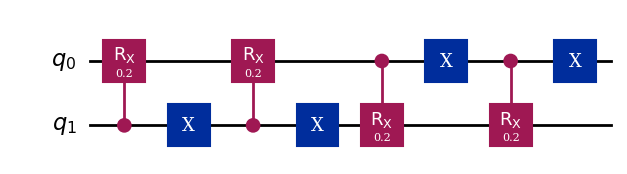


Detailed Gate Count Summary for Cycle Graph C4:
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 |  16/  8/    24              |   2/  0/     2             |   2/  0/     2            |   2/  0/     2
      2 |  32/ 16/    48              |   2/  0/     2             |   4/  0/     4            |   2/  0/     2
      5 |  80/ 40/   120              |   2/  0/     2             |  10/  0/    10            |   2/  0/     2
     10 | 160/ 80/   240              |   2/  0/     2             |  20/  0/    20            |   2/  0/     2
     20 | 320/160/   480              |   2/  0/     2             |  40/  0/    40            |   2/  0/     2
     50 | 800/400/  1200              |   2/  0/     2             | 100/  0/   100            |   2/  0/     2
    100 | 1600/800/  2400         

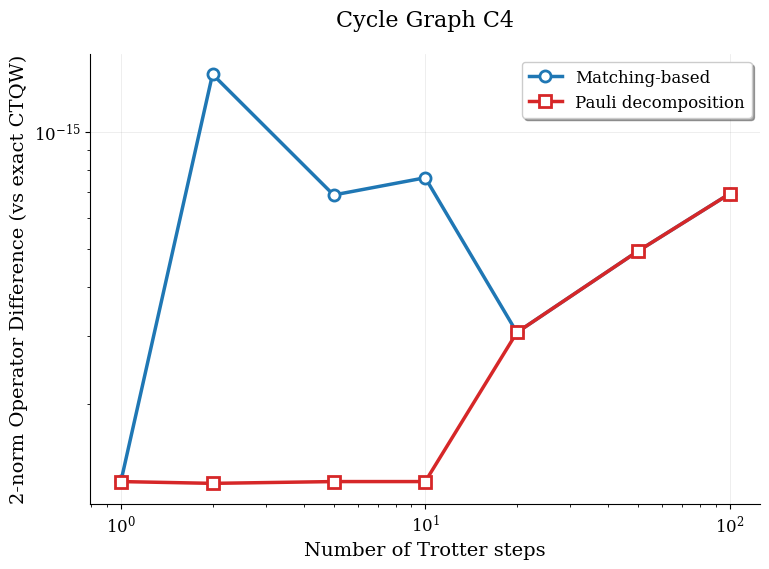

In [4]:
# Test Case 1: Simple 2-qubit system (exact case)
def circuit_builder_1(n_qubits, n_steps, delta_t):
    full_qc = QuantumCircuit(n_qubits)
    for i in range(n_steps):
        # full_qc.rx(2 * delta_t/n_steps, 0)
        # full_qc.rx(2 * delta_t/n_steps, 1)
        mcrx0 = multi_crx(2 * delta_t/n_steps, '0')
        mcrx1 = multi_crx(2 * delta_t/n_steps, '1')
        full_qc.append(mcrx0, [0,1])
        full_qc.append(mcrx1, [0,1])
        full_qc.append(mcrx0, [1,0])
        full_qc.append(mcrx1, [1,0])
    return full_qc

edges_1 = {('00', '10'), ('01', '11'), ('10', '11'), ('00', '01')}
relabeled_edges_1 = {('11', '10'), ('00', '10'), ('01', '11'), ('01', '00')}

analyze_and_plot(edges_1, "Cycle Graph C4")


Complete Graph K4 - C2
Original edges: {('01', '11'), ('00', '10'), ('00', '11'), ('01', '10'), ('00', '01')}
Number of matchings: 3
Matchings: [{('01', '11'), ('10', '00')}, {('10', '11'), ('01', '00')}, {('10', '01')}]
Relabeled edges: {('01', '11'), ('10', '11'), ('01', '00'), ('10', '01'), ('10', '00')}
Number of qubits: 2

Sample Quantum Circuit (n_steps=1):


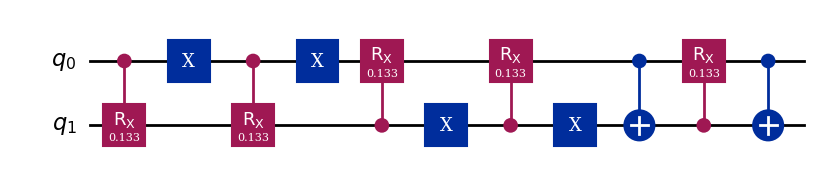


Detailed Gate Count Summary for Complete Graph K4 - C2:
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 |  19/ 12/    31              |   6/  2/     8             |  12/  4/    16            |   6/  2/     8
      2 |  38/ 24/    62              |   8/  3/    11             |  24/  8/    32            |   8/  3/    11
      5 |  95/ 60/   155              |   8/  3/    11             |  60/ 20/    80            |   8/  3/    11
     10 | 190/120/   310              |   8/  3/    11             | 120/ 40/   160            |   8/  3/    11
     20 | 380/240/   620              |   8/  3/    11             | 240/ 80/   320            |   8/  3/    11
     50 | 950/600/  1550              |   8/  3/    11             | 600/200/   800            |   8/  3/    11
    100 | 1900/1200/  3100

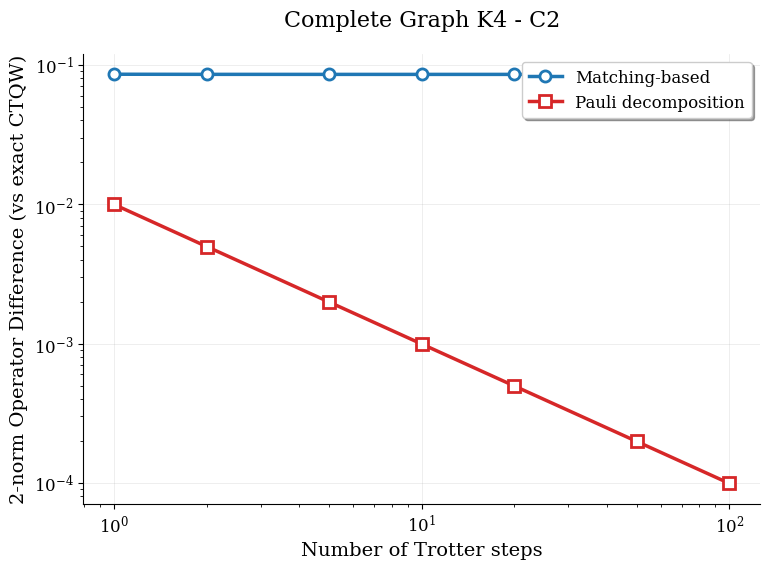

In [5]:
# Test Case 3: Modified CRX without X gates
def circuit_builder_3(n_qubits, n_steps, delta_t):
    full_qc = QuantumCircuit(n_qubits)
    for i in range(n_steps):
        full_qc.cx(0, 1)
        full_qc.crx(2 * delta_t/n_steps, 1, 0)
        full_qc.cx(0, 1)
        mcrx0 = multi_crx(2 * delta_t/n_steps, '0')
        mcrx1 = multi_crx(2 * delta_t/n_steps, '1')
        full_qc.append(mcrx0, [0,1])
        full_qc.append(mcrx1, [0,1])
        full_qc.append(mcrx0, [1,0])
        full_qc.append(mcrx1, [1,0])
    return full_qc

edges_3 = {('00', '11'), ('01', '10'), ('00', '10'), ('01', '11'), ('00', '01')}
relabeled_edges_3 = {('01', '10'), ('00', '10'), ('11', '01'), ('11', '10'), ('00', '01')}

analyze_and_plot(edges_3, "Complete Graph K4 - C2")


Path Graph P3
Original edges: {('10', '11'), ('01', '10'), ('00', '01')}
Number of matchings: 2
Matchings: [{('10', '11'), ('01', '00')}, {('11', '01')}]
Relabeled edges: {('11', '01'), ('10', '11'), ('01', '00')}
Number of qubits: 2

Sample Quantum Circuit (n_steps=1):


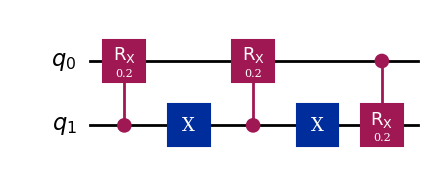


Detailed Gate Count Summary for Path Graph P3:
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 |  11/  6/    17              |   6/  2/     8             |   5/  2/     7            |   4/  2/     6
      2 |  22/ 12/    34              |   6/  2/     8             |  10/  4/    14            |   6/  2/     8
      5 |  55/ 30/    85              |   6/  2/     8             |  25/ 10/    35            |   6/  2/     8
     10 | 110/ 60/   170              |   6/  2/     8             |  50/ 20/    70            |   6/  2/     8
     20 | 220/120/   340              |   6/  2/     8             | 100/ 40/   140            |   6/  2/     8
     50 | 550/300/   850              |   6/  2/     8             | 250/100/   350            |   6/  2/     8
    100 | 1100/600/  1700          

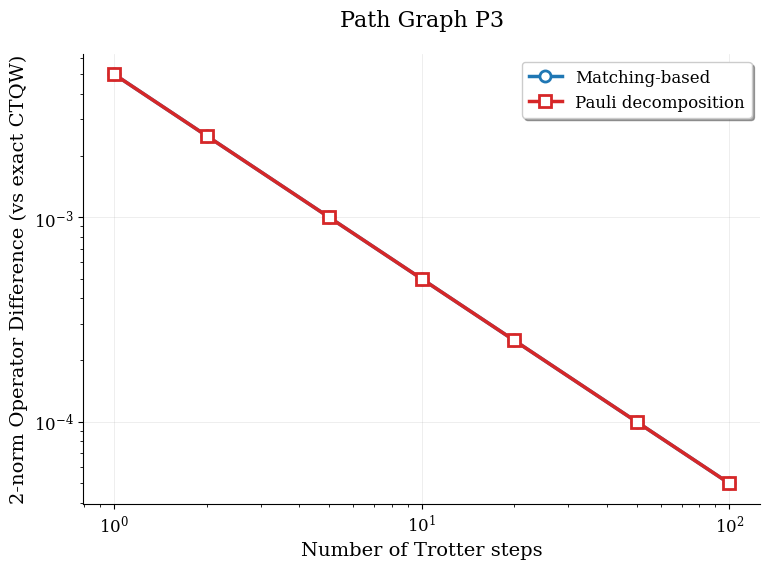

In [6]:
# Test Case 4: Multi-controlled rotation
def circuit_builder_4(n_qubits, n_steps, delta_t):
    full_qc = QuantumCircuit(n_qubits)
    for i in range(n_steps):
        mcrx1 = multi_crx(2 * delta_t/n_steps, '0')
        mcrx2 = multi_crx(2 * delta_t/n_steps, '1')
        
        full_qc.append(mcrx1, [1, 0])
        full_qc.append(mcrx1, [0, 1])
        full_qc.append(mcrx2, [1, 0])
    return full_qc

edges_4 = {('00', '01'), ('01', '10'), ('10', '11')}
relabeled_edges_4 = {('10', '11'), ('00', '10'), ('01', '00')}

analyze_and_plot(edges_4, "Path Graph P3")


Tree Graph T4
Original edges: {('00', '10'), ('00', '11'), ('00', '01')}
Number of matchings: 3
Matchings: [{('01', '10')}, {('01', '11')}, {('01', '00')}]
Relabeled edges: {('01', '11'), ('01', '00'), ('01', '10')}
Number of qubits: 2

Sample Quantum Circuit (n_steps=1):


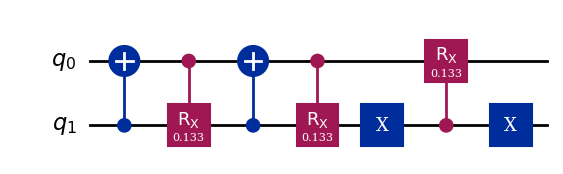


Detailed Gate Count Summary for Tree Graph T4:
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 |  11/  8/    19              |   8/  3/    11             |  18/  8/    26            |   8/  3/    11
      2 |  22/ 16/    38              |   8/  3/    11             |  36/ 16/    52            |   8/  3/    11
      5 |  55/ 40/    95              |   8/  3/    11             |  90/ 40/   130            |   8/  3/    11
     10 | 110/ 80/   190              |   8/  3/    11             | 180/ 80/   260            |   8/  3/    11
     20 | 220/160/   380              |   8/  3/    11             | 360/160/   520            |   8/  3/    11
     50 | 550/400/   950              |   8/  3/    11             | 900/400/  1300            |   8/  3/    11
    100 | 1100/800/  1900          

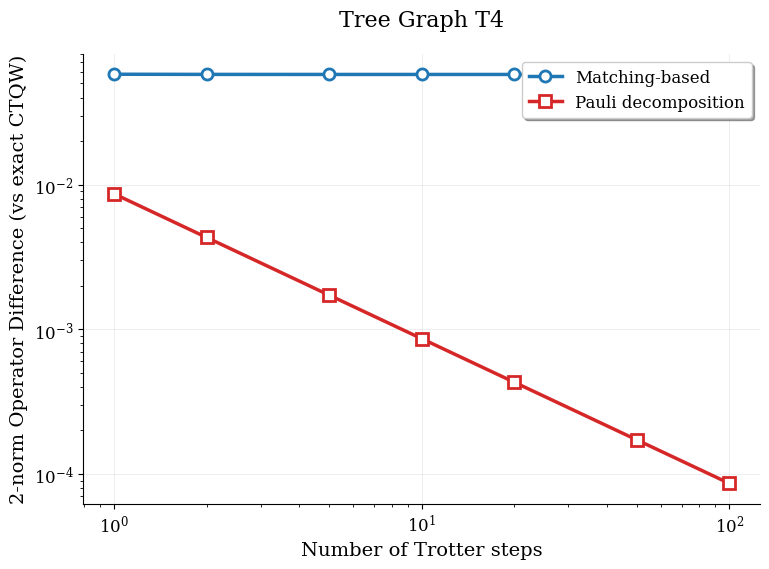

In [7]:


def circuit_builder(n_qubits, n_steps, delta_t):
    full_qc = QuantumCircuit(n_qubits)
    for i in range(n_steps):
        mcrx0 = multi_crx(2 * delta_t/n_steps, '0')
        mcrx1 = multi_crx(2 * delta_t/n_steps, '1')

        full_qc.append(mcrx0, [1,0])
        full_qc.cx(0, 1)
        full_qc.append(mcrx1, [1,0])
        full_qc.cx(0, 1)
        full_qc.append(mcrx1, [0,1])
    return full_qc


# from src.misc import graph_matchings_parallel
# matchings = graph_matchings_parallel(edges)

# relabeled_edges = set()
# for m in matchings:
#     relabeled_edges = relabeled_edges.union(m)

# print(relabeled_edges)
edges = {('00','01'), ('00','10'), ('00','11')}
relabeled_edges = {('01', '10'), ('01', '00'), ('01', '11')}

analyze_and_plot(edges, "Tree Graph T4")


Tree Graph T4
Original edges: {('000', '011'), ('000', '001'), ('000', '010')}
Number of matchings: 3
Matchings: [{('001', '011')}, {('001', '010')}, {('001', '000')}]
Relabeled edges: {('001', '010'), ('001', '011'), ('001', '000')}
Number of qubits: 3

Sample Quantum Circuit (n_steps=1):


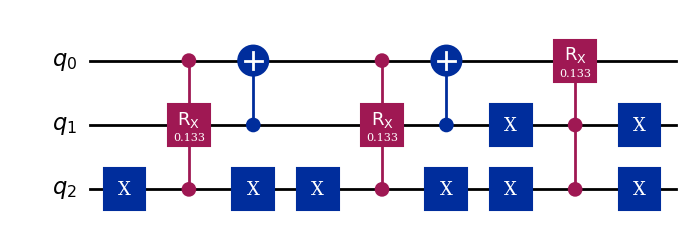


Detailed Gate Count Summary for Tree Graph T4:
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 |  53/ 26/    79              |  28/ 24/    52             |  40/ 28/    68            |  23/ 12/    35
      2 | 106/ 52/   158              |  53/ 48/   101             |  80/ 56/   136            |  45/ 24/    69
      5 | 265/130/   395              | 128/120/   248             | 200/140/   340            | 111/ 60/   171
     10 | 530/260/   790              | 253/240/   493             | 400/280/   680            | 211/120/   331
     20 | 1060/520/  1580              | 503/480/   983             | 800/560/  1360            | 441/240/   681
     50 | 2650/1300/  3950              | 1253/1200/  2453             | 2000/1400/  3400            | 1101/600/  1701
    100 | 5300/2600/  7900 

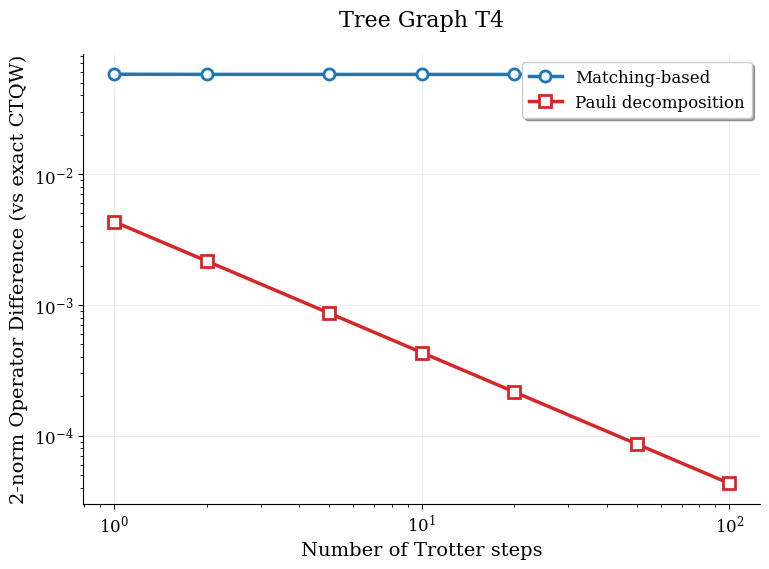

In [8]:

def circuit_builder(n_qubits, n_steps, delta_t):
    full_qc = QuantumCircuit(n_qubits)
    for i in range(n_steps):
        mcrx0 = multi_crx(2 * delta_t/n_steps, '00')
        mcrx1 = multi_crx(2 * delta_t/n_steps, '01')

        full_qc.append(mcrx0, [2,1,0])
        full_qc.cx(0, 1)
        full_qc.append(mcrx1, [2,1,0])
        full_qc.cx(0, 1)
        full_qc.append(mcrx1, [2,0,1])
    return full_qc


# from src.misc import graph_matchings_parallel
# matchings = graph_matchings_parallel(edges)

# relabeled_edges = set()
# for m in matchings:
#     relabeled_edges = relabeled_edges.union(m)

# print(relabeled_edges)
edges = {('000','001'), ('000','010'), ('000','011')}
relabeled_edges = {('001', '010'), ('001', '000'), ('001', '011')}

analyze_and_plot(edges, "Tree Graph T4")